# 10 — Decision Tree Export for Deployment

**Goal:** Print/export the final decision tree's full structure and manually translate it into
C if/else pseudocode, side-by-side with the sklearn output. This notebook's output becomes
`decision_tree_c_reference.txt` — the reference you copy from when writing the actual firmware
code in `firmware/Hydrosense/Core/Src/`.

In [1]:
import pickle
import pandas as pd
from pathlib import Path
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

MODELS_DIR = Path("../results/models")
FIGURES_DIR = Path("../results/figures")
TOOLS_DIR = Path("../tools")
TOOLS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_COLS = ["temperature_C", "humidity_pct", "soil_moisture_pct", "moisture_trend", "light_lux", "hour_of_day"]

with open(MODELS_DIR / "decision_tree.pkl", "rb") as f:
    dt_model = pickle.load(f)

print("Classes:", list(dt_model.classes_))
print("Tree depth:", dt_model.get_depth())
print("Number of leaves:", dt_model.get_n_leaves())

Classes: ['Soon', 'Urgent']
Tree depth: 1
Number of leaves: 2


## Full text export of the tree structure

This is the ground truth you translate from — every split condition and leaf value, in order.

In [2]:
tree_text = export_text(dt_model, feature_names=FEATURE_COLS, decimals=3)
print(tree_text)

|--- soil_moisture_pct <= 79.210
|   |--- class: Urgent
|--- soil_moisture_pct >  79.210
|   |--- class: Soon



In [3]:
# Save raw sklearn export for reference
with open(TOOLS_DIR / "decision_tree_sklearn_export.txt", "w") as f:
    f.write(tree_text)
print("Saved decision_tree_sklearn_export.txt")

Saved decision_tree_sklearn_export.txt


## Visual reference alongside the text export

Helpful for a final visual double-check while translating — easy to lose your place in a deep text-only tree.

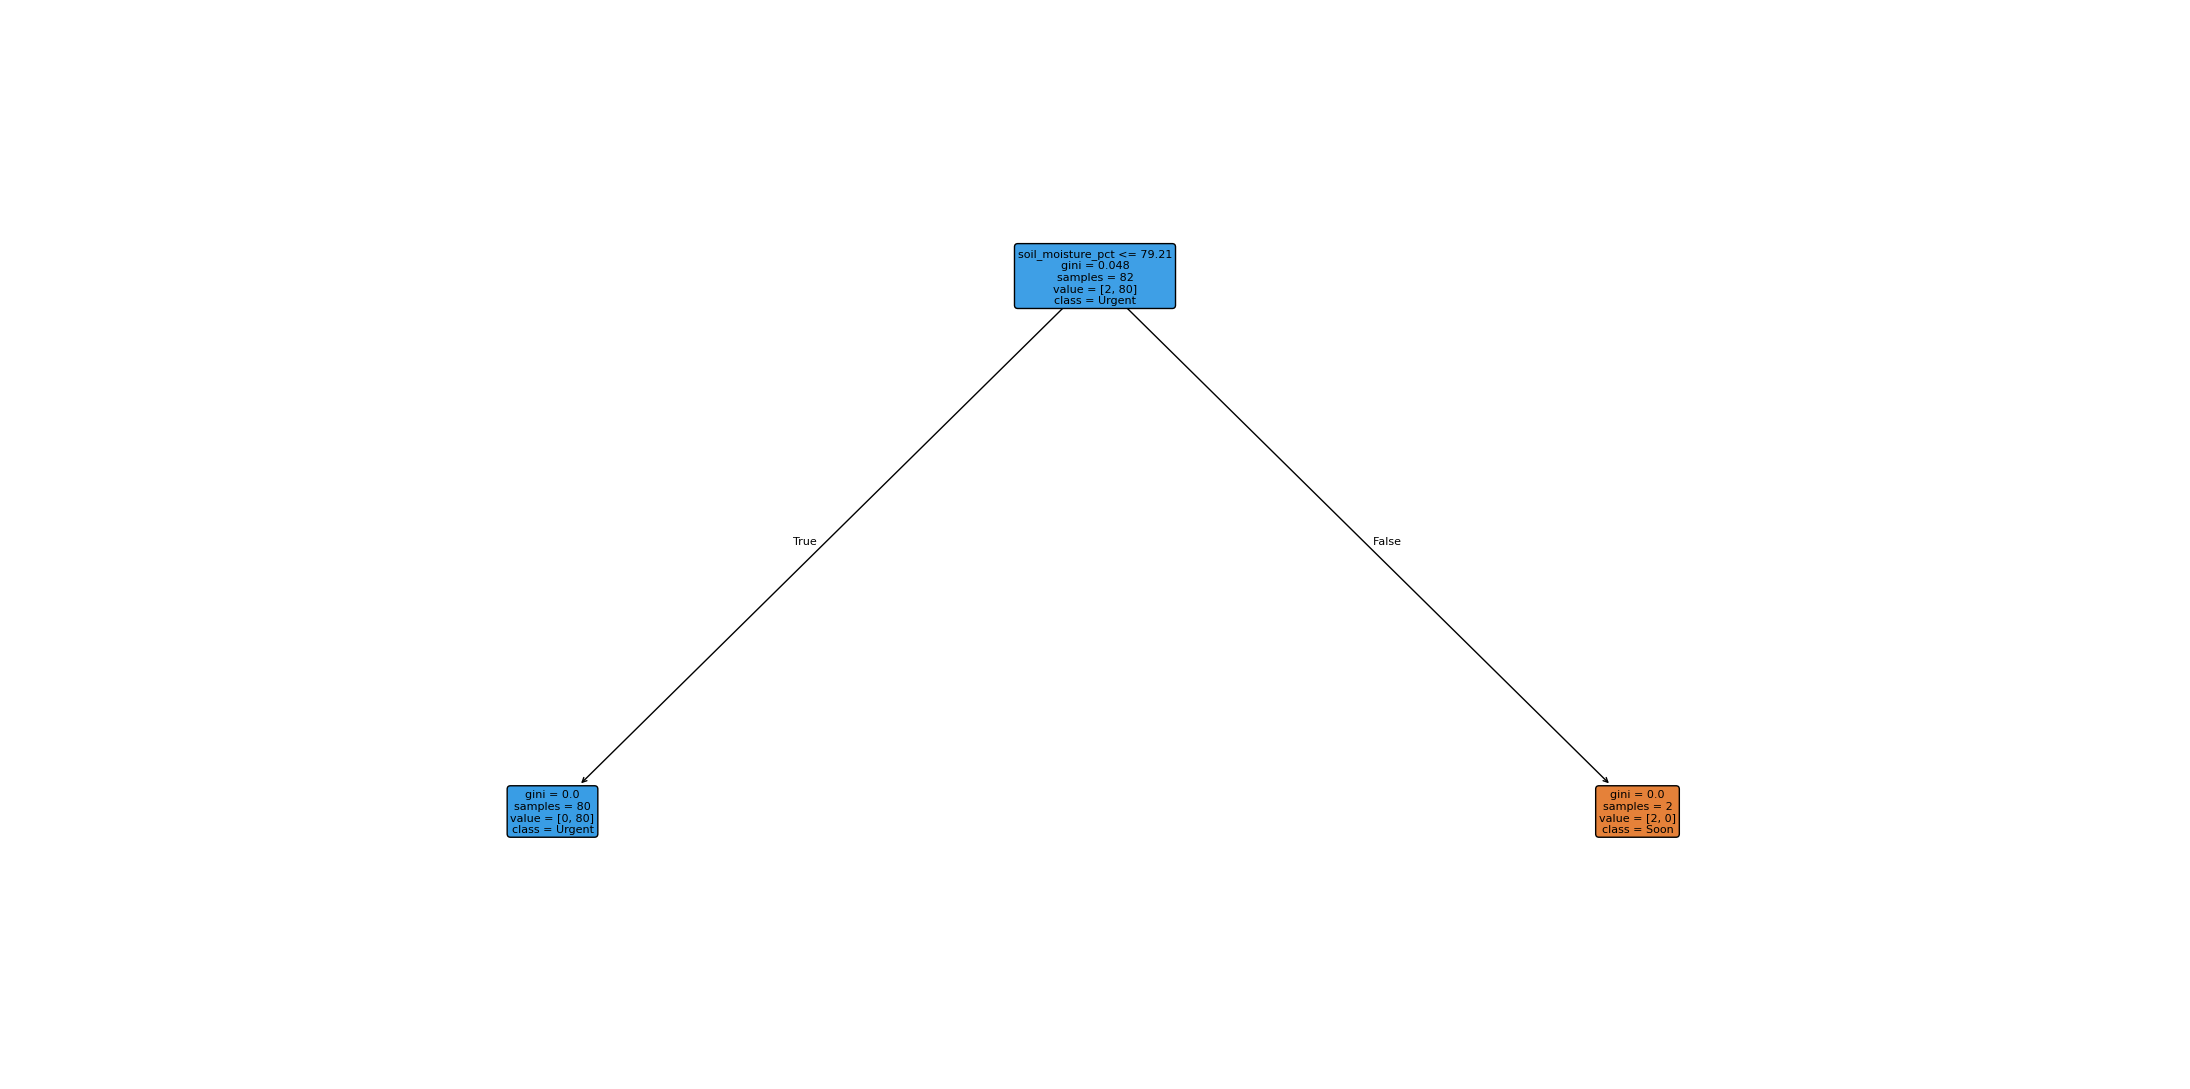

In [4]:
fig, ax = plt.subplots(figsize=(22, 11))
plot_tree(
    dt_model,
    feature_names=FEATURE_COLS,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_decision_tree_for_export.png", dpi=150, bbox_inches="tight")
plt.show()

## Manual translation to C — worked template

Walk the printed tree above top-to-bottom, translating each `if (feature <= threshold)` /
`else` branch directly. Below is a **template shape** matching a typical shallow tree on these
six features — replace the placeholder thresholds/branches with your actual printed tree from
the cell above. Keep the feature order and comparison directions (`<=` vs `>`) exactly as
sklearn printed them; sklearn always uses `<=` on the left branch and `>` on the right.

In [5]:
c_code_template = '''
// Auto-derived reference — replace thresholds/branches with your actual
// printed tree from the export_text() cell above. Enum order must match
// dt_model.classes_ exactly (alphabetical by default: Not_Urgent, Soon, Urgent).

typedef enum {
    URGENCY_NOT_URGENT = 0,
    URGENCY_SOON = 1,
    URGENCY_URGENT = 2
} UrgencyClass;

UrgencyClass predict_urgency(
    float temperature_C,
    float humidity_pct,
    float soil_moisture_pct,
    float moisture_trend,
    float light_lux,
    int   hour_of_day
) {
    // Example shape only — replace conditions/thresholds with your real tree.
    if (soil_moisture_pct <= 40.0f) {
        if (moisture_trend <= -2.5f) {
            return URGENCY_URGENT;
        } else {
            if (light_lux <= 3000.0f) {
                return URGENCY_SOON;
            } else {
                return URGENCY_URGENT;
            }
        }
    } else {
        if (temperature_C <= 30.0f) {
            return URGENCY_NOT_URGENT;
        } else {
            return URGENCY_SOON;
        }
    }
}
'''

print(c_code_template)

with open("../tools/decision_tree_c_reference.txt", "w") as f:
    f.write("SKLEARN EXPORT (source of truth):\n")
    f.write("=" * 60 + "\n")
    f.write(tree_text)
    f.write("\n\n")
    f.write("C TRANSLATION TEMPLATE (fill in from the export above):\n")
    f.write("=" * 60 + "\n")
    f.write(c_code_template)

print("\nSaved decision_tree_c_reference.txt")


// Auto-derived reference — replace thresholds/branches with your actual
// printed tree from the export_text() cell above. Enum order must match
// dt_model.classes_ exactly (alphabetical by default: Not_Urgent, Soon, Urgent).

typedef enum {
    URGENCY_NOT_URGENT = 0,
    URGENCY_SOON = 1,
    URGENCY_URGENT = 2
} UrgencyClass;

UrgencyClass predict_urgency(
    float temperature_C,
    float humidity_pct,
    float soil_moisture_pct,
    float moisture_trend,
    float light_lux,
    int   hour_of_day
) {
    // Example shape only — replace conditions/thresholds with your real tree.
    if (soil_moisture_pct <= 40.0f) {
        if (moisture_trend <= -2.5f) {
            return URGENCY_URGENT;
        } else {
            if (light_lux <= 3000.0f) {
                return URGENCY_SOON;
            } else {
                return URGENCY_URGENT;
            }
        }
    } else {
        if (temperature_C <= 30.0f) {
            return URGENCY_NOT_URGENT;
        } else {
        

## Verification step (do this before trusting the C port)

Once you've written the real C translation, verify it against a handful of real rows from
`labeled_dataset.csv`: run the same feature values through both `dt_model.predict()` here in
Python and through your compiled C function on-device (or a desktop test harness), and confirm
they agree on every test row. This is the concrete check that the hand-translation was faithful
— don't skip it, since a transcription error here would silently make your deployed predictions
wrong while your evaluation numbers (based on the Python model) stay looking fine.

In [6]:
# Spot-check template: run a few real feature rows through the Python model
# and record expected outputs to compare against the C version's output.
import pandas as pd

PREPROCESSED_DIR = Path("../data/preprocessed")
labeled_df = pd.read_csv(PREPROCESSED_DIR / "labeled_dataset.csv")

sample_rows = labeled_df.sample(n=min(5, len(labeled_df)), random_state=1)
X_sample = sample_rows[FEATURE_COLS]
predictions = dt_model.predict(X_sample)

verification_table = X_sample.copy()
verification_table["python_prediction"] = predictions
verification_table["c_prediction"] = ""  # fill in after running the C version on-device

verification_table.to_csv("../tools/c_port_verification_rows.csv", index=False)
print("Saved c_port_verification_rows.csv — fill in 'c_prediction' after testing the C port")
verification_table

Saved c_port_verification_rows.csv — fill in 'c_prediction' after testing the C port


,temperature_C,humidity_pct,soil_moisture_pct,moisture_trend,light_lux,hour_of_day,python_prediction,c_prediction
10,25.59,56.53,56.66,-7.09,170.6,22,Urgent,
70,29.37,66.57,61.90,-10.80,7996.3,1,Urgent,
47,27.32,55.38,27.97,-8.01,163.7,16,Urgent,
54,30.27,67.58,62.42,-10.13,7544.2,4,Urgent,
40,26.93,55.02,46.38,-8.02,187.7,9,Urgent,
